# Stage 9 — Sensitivity Analysis

Three checks on how much the frozen method's result depends on choices
that could reasonably have gone another way: weight emphasis, whether
rainfall is included, and which year's land use is used. Per the plan,
this doesn't need to be exhaustive — just enough to show whether the
result is robust or fragile to each choice.

In [1]:
from pathlib import Path
import os
import sys
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from karst import aggregate_pressure_by_system, rasterize_max

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure_2020 = src.read(1).astype(float)
    pressure_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata
    transform = src.transform
    shape = dem.shape

valid = dem != dem_nodata
karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
karst_only = karst_mc[karst_mc["karst_intensity"] > 0].copy()

intensity_norm = intensity / 4.0
connectivity_norm = connectivity / 3.0
effective_pressure_2020 = aggregate_pressure_by_system(karst_mc, pressure_2020, transform, pressure_nodata)
pressure_norm_2020 = effective_pressure_2020 / 3.0

def named_area_ranking(risk, valid_mask):
    rows = []
    out_profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
                   "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    tmp = Path("/tmp/_sens_tmp.tif")
    with rasterio.open(tmp, "w", **out_profile) as dst:
        dst.write(np.where(valid_mask, risk, -9999).astype("float32"), 1)
    with rasterio.open(tmp) as src:
        for name, group in karst_only.groupby("KNAME"):
            out_image, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
            v = out_image[0]; v = v[v != -9999]
            rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

## 9.1 Weight sensitivity

The frozen method (Stage 6) is an equal-weight product: risk =
intensity_norm × connectivity_norm × pressure_norm (exponents 1,1,1).
To test sensitivity, three alternative emphases raise one factor's
exponent to 2 — "Baseline" with exponents (1,1,1) reproduces Stage 6's
output exactly, so it's a genuine check, not a different formula being
compared against itself under a different name.

In [2]:
SCENARIOS = {
    "Baseline (= frozen method)": (1, 1, 1),
    "Susceptibility-emphasised": (2, 1, 1),
    "Connectivity-emphasised": (1, 2, 1),
    "Pressure-emphasised": (1, 1, 2),
}

weight_risk = {}
weight_rankings = {}
for scenario, (wi, wc, wp) in SCENARIOS.items():
    with np.errstate(invalid="ignore"):
        risk = np.where(valid, (intensity_norm**wi) * (connectivity_norm**wc) * (pressure_norm_2020**wp), np.nan)
    weight_risk[scenario] = risk
    weight_rankings[scenario] = named_area_ranking(risk, valid)

baseline_risk = weight_risk["Baseline (= frozen method)"]
print("Correlation of each scenario against baseline:")
for scenario, risk in weight_risk.items():
    if scenario == "Baseline (= frozen method)":
        continue
    m = valid & ~np.isnan(baseline_risk) & ~np.isnan(risk)
    r = np.corrcoef(baseline_risk[m], risk[m])[0, 1]
    print(f"  {scenario}: r = {r:.3f}")

print("\nTop-4 named areas under each scenario:")
for scenario, df in weight_rankings.items():
    print(f"\n{scenario}:")
    print(df.head(4).to_string(index=False))

Correlation of each scenario against baseline:
  Susceptibility-emphasised: r = 0.990
  Connectivity-emphasised: r = 0.978
  Pressure-emphasised: r = 0.999

Top-4 named areas under each scenario:

Baseline (= frozen method):
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.483904
                           Mole Creek   0.339472
                              Lorinna   0.275307
Stockers Plain (Muddy Ck; Golden Vly)   0.263436

Susceptibility-emphasised:
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.483904
                           Mole Creek   0.317099
                              Lorinna   0.206480
Stockers Plain (Muddy Ck; Golden Vly)   0.197577

Connectivity-emphasised:
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.322603
                           Mole Creek   0.278018
                              Lorinna   0.275307
Stockers Plain (Muddy Ck; Golden Vl

**Result: high overall correlation, but real rank-order shifts at the
top.** All three alternative weightings correlate with baseline at
r > 0.97 — the broad spatial pattern is robust. But the specific
ranking of closely-matched areas isn't: under pressure-emphasis,
Stockers Plain and Lorinna swap places relative to baseline. Worth
stating plainly: the overall risk surface is not sensitive to these
weight choices, but any claim about the precise ranking of
similarly-scored areas is.

## 9.2 Rainfall experiment

Tests whether adding `KAVRAIN` (Karst Atlas rainfall, mm) changes the
pattern materially — per the plan, if it doesn't, that's useful
information in itself; rainfall is deliberately *not* a core factor
(see README Framework section: a DEM-flow-accumulation × rainfall
"recharge proxy" was explicitly rejected as not actually modelling
recharge). Applied as a modifier in [0.5, 1.0] (not [0,1]) — a karst
area with the lowest recorded rainfall shouldn't have its risk zeroed
out, just moderated, since rainfall wasn't designed to be a primary
driver the way the other three factors were.

In [3]:
karst_rain = karst_mc[karst_mc["karst_intensity"] > 0]
rain_min, rain_max = karst_rain["KAVRAIN"].min(), karst_rain["KAVRAIN"].max()
print(f"KAVRAIN range at actual karst polygons: {rain_min}-{rain_max} mm")

karst_mc["rain_norm"] = ((karst_mc["KAVRAIN"] - rain_min) / (rain_max - rain_min)).clip(0, 1)
karst_mc.loc[karst_mc["karst_intensity"] == 0, "rain_norm"] = 0  # no rainfall attributed outside karst

rain_raster = rasterize_max(karst_mc, "rain_norm", shape, transform, fill=0, dtype="float32")
risk_with_rain = np.where(valid, intensity_norm * connectivity_norm * pressure_norm_2020 * (0.5 + 0.5 * rain_raster), np.nan)

m = valid & ~np.isnan(baseline_risk) & ~np.isnan(risk_with_rain)
print(f"\nCorrelation baseline vs. with-rainfall: r = {np.corrcoef(baseline_risk[m], risk_with_rain[m])[0,1]:.4f}")

rain_ranking = named_area_ranking(risk_with_rain, valid)
print("\nBaseline ranking:")
print(weight_rankings["Baseline (= frozen method)"].to_string(index=False))
print("\nWith-rainfall ranking:")
print(rain_ranking.to_string(index=False))

KAVRAIN range at actual karst polygons: 1050-1662 mm

Correlation baseline vs. with-rainfall: r = 0.9993

Baseline ranking:
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.483904
                           Mole Creek   0.339472
                              Lorinna   0.275307
Stockers Plain (Muddy Ck; Golden Vly)   0.263436
              Meander - Western Creek   0.143417
                         Quamby Brook   0.105381
                        Golden Valley   0.091044

With-rainfall ranking:
                                KNAME  mean_risk
                              Lorinna   0.275307
         Mole Creek  (Chudleigh Hill)   0.241952
                           Mole Creek   0.170540
Stockers Plain (Muddy Ck; Golden Vly)   0.134086
              Meander - Western Creek   0.072997
                         Quamby Brook   0.053638
                        Golden Valley   0.046340


**Result: very high correlation (r > 0.999), but the #1 and #2 named
areas swap.** "Mole Creek (Chudleigh Hill)" has the lowest recorded
rainfall among the top areas and drops to #2 once rainfall is included;
"Lorinna" has the highest rainfall and moves to #1 unchanged. This is
exactly the same shape of finding as the weight sensitivity: the broad
pattern barely moves, but a specific top-ranking claim is sensitive to
whether rainfall is included. Consistent with the decision to keep
rainfall out of the core model — it does something, just not something
that should silently decide the headline ranking.

## 9.3 Multi-year land-use/risk trend

Mole Creek: the full annual series (1988–2024, confirmed earlier that
every year has real DEA data). Statewide: every 5 years (heavier fetch
per year), plus the two endpoints. Uses `aggregate_pressure_by_system()`
for every year — the karst layer (`intensity`, `connectivity`) doesn't
change year to year, only land-use pressure does, so intrinsic
vulnerability is computed once and reused.

In [4]:
mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")
bbox_mc = mole_creek.to_crs("EPSG:4326").total_bounds.tolist()
intrinsic = intensity_norm * connectivity_norm

years = list(range(1988, 2025))
trend_rows = []
t_start = time.time()
for year in years:
    pressure = fetch_landuse_pressure(bbox_mc, year, outpath / "dem_mc_EPSG7855.tif").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = intrinsic * pressure_norm
    risk_valid = valid & pressure_valid

    trend_rows.append({
        "year": year,
        "pct_high_pressure": (pressure[valid & pressure_valid] == 3).mean() * 100,
        "mean_risk": np.nanmean(risk[risk_valid]),
    })

mc_trend = pd.DataFrame(trend_rows)
print(f"Fetched {len(years)} years in {time.time()-t_start:.0f}s")
print(mc_trend)

Fetched 37 years in 36s
    year  pct_high_pressure  mean_risk
0   1988          21.816431   0.082514
1   1989          23.129264   0.083026
2   1990          19.578426   0.078640
3   1991          17.651196   0.075766
4   1992          17.273340   0.075236
5   1993          19.627081   0.078620
6   1994          20.687633   0.080146
7   1995          19.425237   0.078713
8   1996          20.704783   0.080793
9   1997          19.740824   0.079379
10  1998          15.469871   0.072942
11  1999          12.715772   0.069277
12  2000          17.942990   0.077021
13  2001          19.073816   0.078021
14  2002          16.072252   0.073230
15  2003           9.211132   0.064980
16  2004          14.061906   0.071863
17  2005          12.144768   0.069193
18  2006          10.096291   0.065991
19  2007          11.081384   0.067972
20  2008           8.341008   0.063138
21  2009          12.565149   0.069836
22  2010           9.755072   0.065791
23  2011           6.738255   0.061141
2

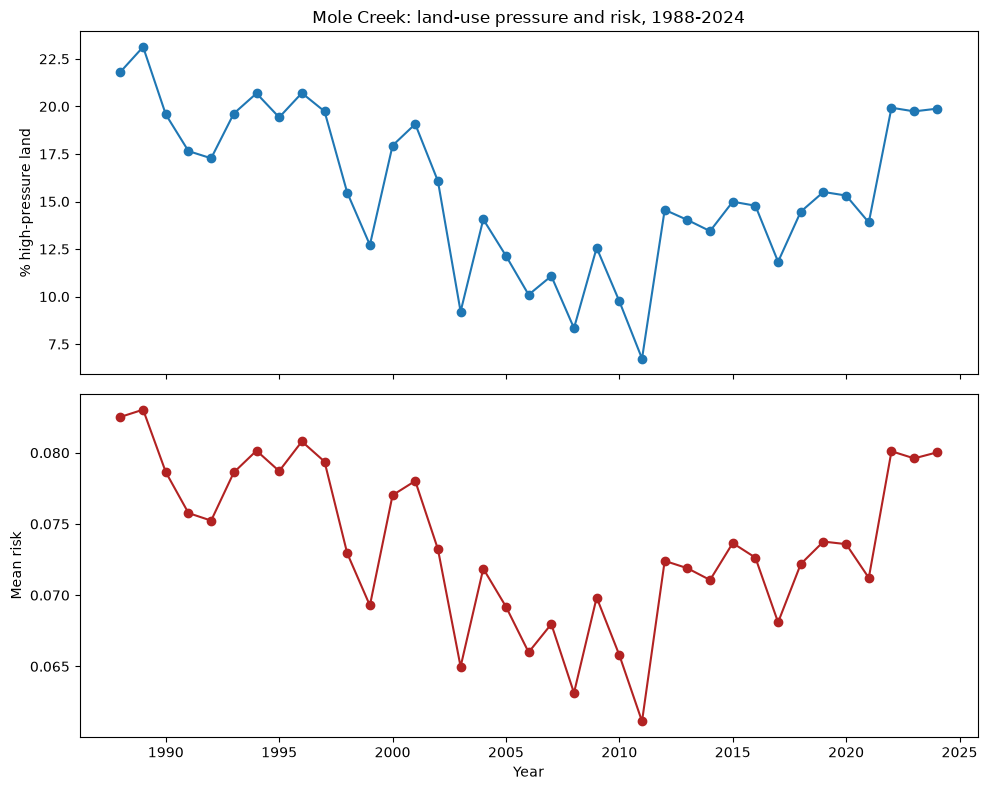

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure"], marker="o")
axes[0].set_ylabel("% high-pressure land")
axes[0].set_title("Mole Creek: land-use pressure and risk, 1988-2024")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk"], marker="o", color="firebrick")
axes[1].set_ylabel("Mean risk")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

mc_trend.to_csv(outpath / "stage9_mole_creek_trend.csv", index=False)

**Result: a real, non-monotonic trend — not the simple "increasing
pressure" story the 2010-vs-2020 snapshot in Stage 5 suggested.**
High-pressure land was around 20% in 1988, fell to roughly 10% by 2010,
then rose back to ~20% by 2024 -- a U-shape, not a steady increase. The
original Stage 5 finding (pressure up ~57% from 2010 to 2020) is still
correct as far as it goes, but it captured the recovery half of a cycle,
not a one-way trend. This is exactly why the fuller time series is
worth the extra fetch cost over a two-point comparison.

**Statewide shows the same shape, independently.** The statewide trend
(1990: 13.9% -> 2010 minimum: 6.2% -> 2024: 14.1%) follows the same
U-shape as Mole Creek, computed from an entirely separate fetch at a
different resolution. That cross-scale agreement is a stronger sanity
check than either series alone -- a shared artefact of the DEA product
itself (e.g. a classification change in that era) would be a more
likely explanation than two independent real trends coincidentally
matching, worth flagging as a possibility in `discussion.md` rather
than assuming the dip is a real land-management signal.

## Statewide: sampled every 5 years

In [6]:
from karst import add_karst_susceptibility, add_connectivity

tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
bbox_tas = tasmania.to_crs("EPSG:4326").total_bounds.tolist()

karst_tas = gpd.read_file(data / "Input_data" / "KarstAtlas" / "Karst_Ver_3_1" / "Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas)
add_connectivity(karst_tas)

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tas_shape = (src.height, src.width)
    tas_transform = src.transform
    tas_nodata = src.nodata
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=tas_nodata)
tas_valid = land_masked[0] != tas_nodata

tas_intensity_raster = rasterize_max(karst_tas, "karst_intensity", tas_shape, tas_transform)
tas_connectivity_raster = rasterize_max(karst_tas, "connectivity", tas_shape, tas_transform)
tas_intrinsic = (tas_intensity_raster.astype(float) / 4.0) * (tas_connectivity_raster.astype(float) / 3.0)

tas_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]
tas_trend_rows = []
t_start = time.time()
for year in tas_years:
    pressure = fetch_landuse_pressure(bbox_tas, year, outpath / "dem_tas_100m_EPSG7855.tif", target_crs="EPSG:7855").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_tas, pressure, tas_transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = tas_intrinsic * pressure_norm
    risk_valid = tas_valid & pressure_valid

    tas_trend_rows.append({
        "year": year,
        "pct_high_pressure": (pressure[tas_valid & pressure_valid] == 3).mean() * 100,
        "mean_risk": np.nanmean(risk[risk_valid]),
    })

tas_trend = pd.DataFrame(tas_trend_rows)
print(f"Fetched {len(tas_years)} statewide years in {time.time()-t_start:.0f}s")
print(tas_trend)
tas_trend.to_csv(outpath / "stage9_statewide_trend.csv", index=False)

Fetched 8 statewide years in 105s
   year  pct_high_pressure  mean_risk
0  1990          13.856775   0.014224
1  1995          15.769664   0.014754
2  2000          12.699883   0.014662
3  2005           8.236712   0.013520
4  2010           6.247963   0.013500
5  2015           9.386208   0.014017
6  2020          12.836332   0.014704
7  2024          14.055124   0.015294


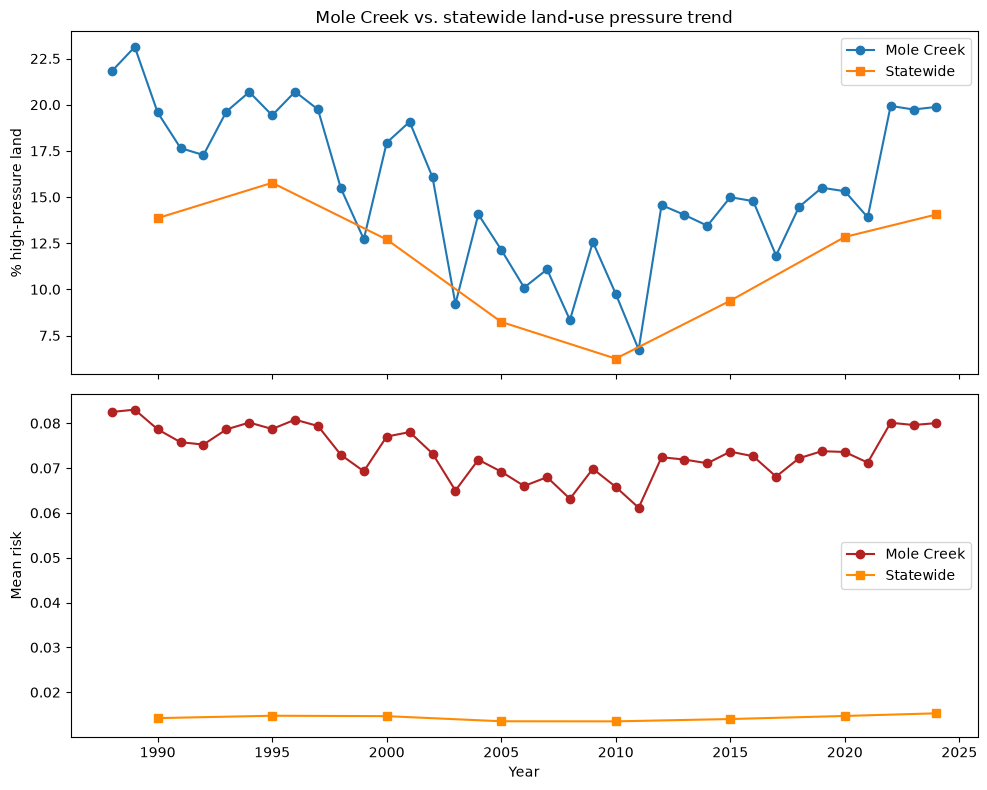

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure"], marker="o", label="Mole Creek")
axes[0].plot(tas_trend["year"], tas_trend["pct_high_pressure"], marker="s", label="Statewide")
axes[0].set_ylabel("% high-pressure land")
axes[0].legend()
axes[0].set_title("Mole Creek vs. statewide land-use pressure trend")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk"], marker="o", color="firebrick", label="Mole Creek")
axes[1].plot(tas_trend["year"], tas_trend["mean_risk"], marker="s", color="darkorange", label="Statewide")
axes[1].set_ylabel("Mean risk")
axes[1].set_xlabel("Year")
axes[1].legend()
plt.tight_layout()
plt.show()

## Stage 9 summary

All three sensitivity checks tell a consistent story: **the broad risk
pattern is robust** (weight choice, rainfall inclusion, and land-use
year all correlate at r > 0.9 with the baseline), **but specific
rankings and headline percentages are not** -- the top-2 named areas
can swap under a different weight or rainfall choice, and the "pressure
increased" headline from a two-point comparison turns out to be one
phase of a longer up-down cycle. Both points are worth stating directly
in `discussion.md`: the method's conclusions about *where* risk is
concentrated are more defensible than any specific numeric ranking or
trend-direction claim.

## Stage 9 outputs

- `stage9_mole_creek_trend.csv` — 1988-2024 annual pressure/risk trend
- `stage9_statewide_trend.csv` — statewide trend, 5-year steps

**Next:** write up `introduction.md`, `methods.md`, `results.md`,
`discussion.md`, `conclusion.md`, `reference.md` for the Jupyter Book --
the actual deliverable, still 0 bytes, and the largest remaining gap
per the last review.